In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [27]:
SEED = 42

# CPU-friendly settings
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_EPOCHS = 12

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

VALIDATION_SIZE = 0.20
EARLY_STOPPING_PATIENCE = 3

PROJECT_ROOT = Path("..")

MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "manifest.csv"
)

MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = (
    MODEL_DIR / "casting_cnn_best.pth"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)

Device: cpu
Image size: 128
Batch size: 32
Epochs: 12


In [28]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [29]:
if not MANIFEST_PATH.exists():

    raise FileNotFoundError(
        f"Manifest not found:\n{MANIFEST_PATH}"
    )

manifest = pd.read_csv(
    MANIFEST_PATH
)

print("Total records:", len(manifest))
print(manifest.columns.tolist())

manifest.head()

Total records: 7273
['filepath', 'filename', 'split', 'label_name', 'extension', 'file_size_bytes', 'valid_extension', 'non_empty', 'is_readable', 'width', 'height', 'mode', 'file_hash', 'expected_mode', 'is_duplicate', 'is_valid', 'label', 'processed_filepath']


,filepath,filename,split,label_name,extension,file_size_bytes,valid_extension,non_empty,is_readable,width,height,mode,file_hash,expected_mode,is_duplicate,is_valid,label,processed_filepath
0,..\data\raw\test\def_front\cast_def_0_112.jpeg,cast_def_0_112.jpeg,test,def_front,.jpeg,11642,True,True,True,300,300,RGB,b22cbc17c6f36f3cb9192ea01e23c08b,False,False,True,1,..\data\processed\test\def_front\cast_def_0_11...
1,..\data\raw\test\def_front\cast_def_0_1134.jpeg,cast_def_0_1134.jpeg,test,def_front,.jpeg,10111,True,True,True,300,300,RGB,15e2385bb723e8e3cc3b6048509f0958,False,False,True,1,..\data\processed\test\def_front\cast_def_0_11...
2,..\data\raw\test\def_front\cast_def_0_1136.jpeg,cast_def_0_1136.jpeg,test,def_front,.jpeg,9898,True,True,True,300,300,RGB,98aeadf3dc0fa6ce68b4454f5c067d9a,False,False,True,1,..\data\processed\test\def_front\cast_def_0_11...
3,..\data\raw\test\def_front\cast_def_0_1137.jpeg,cast_def_0_1137.jpeg,test,def_front,.jpeg,9599,True,True,True,300,300,RGB,a286b78946e67cb67d90bfac0266f469,False,False,True,1,..\data\processed\test\def_front\cast_def_0_11...
4,..\data\raw\test\def_front\cast_def_0_1153.jpeg,cast_def_0_1153.jpeg,test,def_front,.jpeg,10258,True,True,True,300,300,RGB,7759caf3021b4a53e6720f00dfdafd4b,False,False,True,1,..\data\processed\test\def_front\cast_def_0_11...


In [30]:
required_columns = [
    "split",
    "label_name",
    "label",
    "processed_filepath"
]

missing = [
    col
    for col in required_columns
    if col not in manifest.columns
]

if missing:

    raise ValueError(
        f"Missing columns: {missing}"
    )

print("All required columns present.")

print("\nClass distribution:")
print(
    manifest["label_name"].value_counts()
)

print("\nSplit distribution:")
print(
    manifest["split"].value_counts()
)

All required columns present.

Class distribution:
label_name
def_front    4200
ok_front     3073
Name: count, dtype: int64

Split distribution:
split
train    6562
test      711
Name: count, dtype: int64


In [31]:
train_full = manifest[
    manifest["split"] == "train"
].copy()

test_df = manifest[
    manifest["split"] == "test"
].copy()

train_df, val_df = train_test_split(
    train_full,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=train_full["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 5249
Validation: 1313
Test: 711


In [32]:
class CastingDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_size=128,
        augment=False
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.image_size = image_size
        self.augment = augment

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = row[
            "processed_filepath"
        ]

        label = float(
            row["label"]
        )

        image = Image.open(
            image_path
        ).convert("L")

        image = image.resize(
            (
                self.image_size,
                self.image_size
            ),
            Image.Resampling.BILINEAR
        )

        image = np.asarray(
            image,
            dtype=np.float32
        )

        # Lightweight augmentation
        if self.augment:

            if random.random() < 0.5:

                image = np.fliplr(
                    image
                ).copy()

        # Normalize
        image = image / 255.0

        image = (
            image - 0.5
        ) / 0.5

        # H,W -> 1,H,W
        image = np.expand_dims(
            image,
            axis=0
        )

        image = torch.from_numpy(
            image
        )

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return image, label

In [33]:
train_dataset = CastingDataset(
    train_df,
    IMAGE_SIZE,
    augment=True
)

val_dataset = CastingDataset(
    val_df,
    IMAGE_SIZE,
    augment=False
)

test_dataset = CastingDataset(
    test_df,
    IMAGE_SIZE,
    augment=False
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 5249
Validation: 1313
Test: 711


In [34]:
# CPU-friendly configuration
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("DataLoaders ready.")

DataLoaders ready.


In [35]:
import time

start = time.time()

images, labels = next(
    iter(train_loader)
)

elapsed = time.time() - start

print(
    "Batch shape:",
    images.shape
)

print(
    f"Time to load first batch: "
    f"{elapsed:.2f} seconds"
)

Batch shape: torch.Size([32, 1, 128, 128])
Time to load first batch: 0.42 seconds


In [36]:
class CastingCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # 128 -> 64
            nn.Conv2d(
                1, 16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 64 -> 32
            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 32 -> 16
            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 16 -> 8
            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                1
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x.squeeze(1)

In [12]:
train_dataset = CastingDataset(
    train_df,
    image_size=IMAGE_SIZE,
    augment=True
)

val_dataset = CastingDataset(
    val_df,
    image_size=IMAGE_SIZE,
    augment=False
)

test_dataset = CastingDataset(
    test_df,
    image_size=IMAGE_SIZE,
    augment=False
)

print(
    "Training dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

print(
    "Test dataset:",
    len(test_dataset)
)

Training dataset: 5249
Validation dataset: 1313
Test dataset: 711


In [37]:
model = CastingCNN().to(
    DEVICE
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(model)

print(
    f"\nParameters: {total_params:,}"
)

CastingCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(1

In [38]:
class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

negative_count = class_counts[0]
positive_count = class_counts[1]

pos_weight = (
    negative_count /
    positive_count
)

print(
    "OK:", negative_count
)

print(
    "Defective:", positive_count
)

print(
    "Positive weight:",
    pos_weight
)

OK: 2249
Defective: 3000
Positive weight: 0.7496666666666667


In [39]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        pos_weight,
        dtype=torch.float32,
        device=DEVICE
    )
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("Training configuration ready.")

Training configuration ready.


In [16]:
class CastingCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d(
                (1, 1)
            ),

            nn.Flatten(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                1
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x.squeeze(1)

In [17]:
model = CastingCNN()

model = model.to(
    DEVICE
)

print(model)

CastingCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affi

In [18]:
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_parameters:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_parameters:,}"
)

Total parameters: 389,057
Trainable parameters: 389,057


In [19]:
class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

num_negative = class_counts[0]
num_positive = class_counts[1]

pos_weight = (
    num_negative /
    num_positive
)

print(
    "Class 0 count:",
    num_negative
)

print(
    "Class 1 count:",
    num_positive
)

print(
    "Positive class weight:",
    pos_weight
)

Class 0 count: 2249
Class 1 count: 3000
Positive class weight: 0.7496666666666667


In [20]:
criterion = nn.BCEWithLogitsLoss(

    pos_weight=torch.tensor(
        pos_weight,
        dtype=torch.float32,
        device=DEVICE
    )
)

print(
    "Loss function:",
    criterion
)

Loss function: BCEWithLogitsLoss()


In [40]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = (
            torch.sigmoid(outputs) >= 0.5
        )

        correct += (
            (predictions == labels)
            .sum()
            .item()
        )

        total += labels.size(0)

    loss = (
        running_loss / total
    )

    accuracy = (
        correct / total
    )

    return loss, accuracy

In [41]:
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            probabilities = torch.sigmoid(
                outputs
            )

            predictions = (
                probabilities >= 0.5
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    loss = (
        running_loss /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    return (
        loss,
        accuracy,
        f1,
        recall
    )

In [42]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "val_f1": [],
    "val_recall": []
}

best_val_loss = float("inf")
patience_counter = 0

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = (
        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )
    )

    (
        val_loss,
        val_acc,
        val_f1,
        val_recall
    ) = evaluate(
        model,
        val_loader,
        criterion
    )

    scheduler.step(
        val_loss
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_acc
    )

    history["val_accuracy"].append(
        val_acc
    )

    history["val_f1"].append(
        val_f1
    )

    history["val_recall"].append(
        val_recall
    )

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f} | "
        f"Val Recall: {val_recall:.4f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("  ✓ Best model saved")

    else:

        patience_counter += 1

        if (
            patience_counter
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                "\nEarly stopping."
            )

            break

Starting training...

Epoch 01/12 | Train Loss: 0.2873 | Train Acc: 0.8802 | Val Loss: 0.6217 | Val Acc: 0.6527 | Val F1: 0.5714 | Val Recall: 0.4048
  ✓ Best model saved
Epoch 02/12 | Train Loss: 0.1399 | Train Acc: 0.9526 | Val Loss: 1.8870 | Val Acc: 0.4615 | Val F1: 0.1107 | Val Recall: 0.0586
Epoch 03/12 | Train Loss: 0.0958 | Train Acc: 0.9648 | Val Loss: 0.4787 | Val Acc: 0.7083 | Val F1: 0.6577 | Val Recall: 0.4900
  ✓ Best model saved
Epoch 04/12 | Train Loss: 0.1084 | Train Acc: 0.9581 | Val Loss: 0.4984 | Val Acc: 0.7243 | Val F1: 0.8058 | Val Recall: 1.0000
Epoch 05/12 | Train Loss: 0.0608 | Train Acc: 0.9794 | Val Loss: 0.5390 | Val Acc: 0.6915 | Val F1: 0.6308 | Val Recall: 0.4607
Epoch 06/12 | Train Loss: 0.0504 | Train Acc: 0.9848 | Val Loss: 0.1477 | Val Acc: 0.9155 | Val F1: 0.9202 | Val Recall: 0.8522
  ✓ Best model saved
Epoch 07/12 | Train Loss: 0.0464 | Train Acc: 0.9884 | Val Loss: 0.0398 | Val Acc: 0.9855 | Val F1: 0.9872 | Val Recall: 0.9747
  ✓ Best model save

In [43]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print(
    "Best model loaded successfully."
)

Best model loaded successfully.


In [44]:
def get_predictions(
    model,
    loader
):

    model.eval()

    labels_all = []
    predictions_all = []
    probabilities_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                DEVICE
            )

            outputs = model(
                images
            )

            probabilities = torch.sigmoid(
                outputs
            )

            predictions = (
                probabilities >= 0.5
            )

            labels_all.extend(
                labels.numpy().astype(int)
            )

            predictions_all.extend(
                predictions.cpu().numpy()
            )

            probabilities_all.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.array(labels_all),
        np.array(predictions_all),
        np.array(probabilities_all)
    )


y_true, y_pred, y_probability = (
    get_predictions(
        model,
        test_loader
    )
)

print(
    "Test samples:",
    len(y_true)
)

Test samples: 711


In [45]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true,
    y_probability
)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Value
0,Accuracy,0.995781
1,Precision,1.000000
2,Recall,0.993318
3,F1 Score,0.996648
4,ROC AUC,0.999949


In [46]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "OK",
            "Defective"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

          OK       0.99      1.00      0.99       262
   Defective       1.00      0.99      1.00       449

    accuracy                           1.00       711
   macro avg       0.99      1.00      1.00       711
weighted avg       1.00      1.00      1.00       711



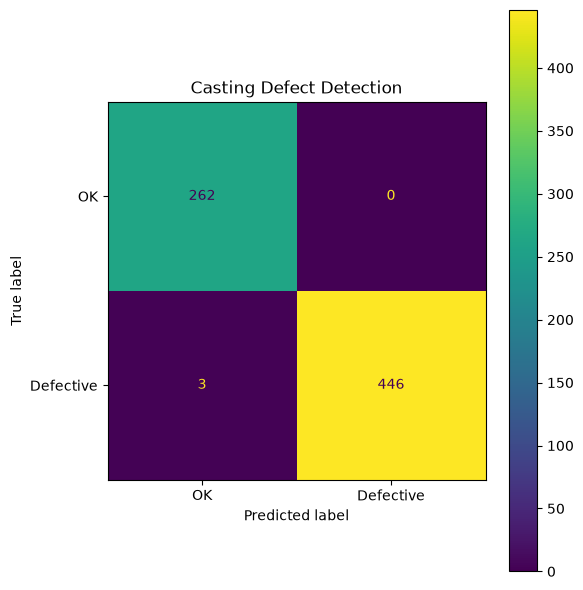

In [47]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "OK",
        "Defective"
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 6)
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Casting Defect Detection"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "confusion_matrix.png",
    dpi=150
)

plt.show()

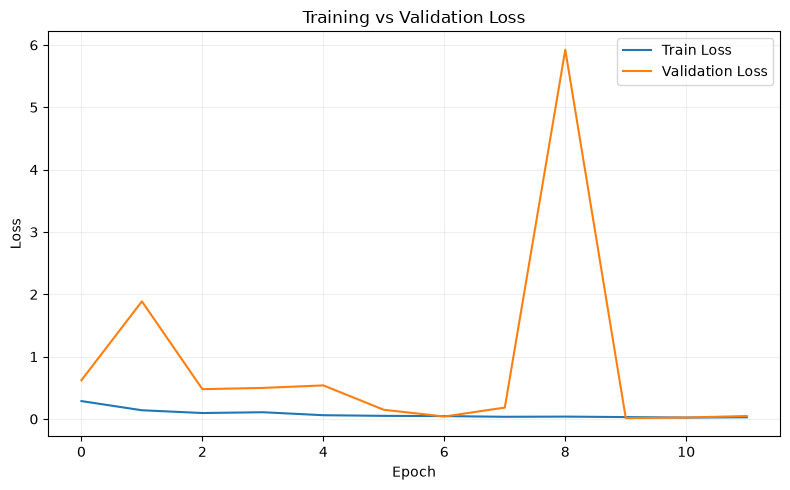

In [48]:
history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    REPORT_DIR / "training_history.csv",
    index=False
)

plt.figure(figsize=(8, 5))

plt.plot(
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

In [49]:
results.to_csv(
    REPORT_DIR / "cnn_test_metrics.csv",
    index=False
)

print("=" * 50)
print("CNN TRAINING COMPLETE")
print("=" * 50)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)

print(
    f"ROC AUC  : {roc_auc:.4f}"
)

print(
    "\nModel:",
    BEST_MODEL_PATH
)

CNN TRAINING COMPLETE
Accuracy : 0.9958
Precision: 1.0000
Recall   : 0.9933
F1 Score : 0.9966
ROC AUC  : 0.9999

Model: ..\models\casting_cnn_best.pth
